In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
import json
from folium.plugins import FloatImage
# df = pd.read_excel('DATASET 2024.xlsx')


In [2]:
# Read the CSV file into a DataFrame
df = pd.read_csv('CompleteData2024.csv')

# Display the DataFrame
print(df.head())
df.shape

                                 address                       bank atm_id  \
0       Rua Tomas Da Fonseca TR a Lisbon             BANCO BPI S.A.  BPI17   
1         Rua Abranches Ferrao 8C Lisbon  BANCO COMERCIAL PORTUGUES   CP52   
2  Avenida Dom Vasco Da Gama 50 a Lisbon      BANCO SANTANDER TOTTA   ST98   
3            Estrada De Telheiras Lisbon  BANCO COMERCIAL PORTUGUES   CP01   
4    Avenida Professor Egas Moniz Lisbon      BANCO SANTANDER TOTTA   ST22   

   coord_x   coord_y       freguesia  parish   mway_dist   police_dis  income  \
0 -9.17093  38.75610          Lumiar      12  195.353440   898.569719      52   
1 -9.17203  38.75064         Carnide      10  766.671635  1432.302696      52   
2 -9.22544  38.69942           Belém       6  192.282794  1143.736479      36   
3 -9.15911  38.76020          Lumiar      12  190.831787   568.679321      56   
4 -9.16161  38.75009  Avenidas Novas       5  724.470391  1292.056182      50   

   density  age  unp_rate  com_dens         

(746, 17)

In [3]:
pd.set_option('display.max_column',None)
df

,address,bank,atm_id,coord_x,coord_y,freguesia,parish,mway_dist,police_dis,income,density,age,unp_rate,com_dens,event_date,freq_attack,success_attack
0,Rua Tomas Da Fonseca TR a Lisbon,BANCO BPI S.A.,BPI17,-9.17093,38.75610,Lumiar,12,195.353440,898.569719,52,8.0558,39,4,9,2015-06-15 19:00:00,4,1
1,Rua Abranches Ferrao 8C Lisbon,BANCO COMERCIAL PORTUGUES,CP52,-9.17203,38.75064,Carnide,10,766.671635,1432.302696,52,4.6250,34,9,18,2010-01-05 15:00:00,3,1
2,Avenida Dom Vasco Da Gama 50 a Lisbon,BANCO SANTANDER TOTTA,ST98,-9.22544,38.69942,Belém,6,192.282794,1143.736479,36,11.5766,50,15,9,2012-10-17 03:20:00,3,0
3,Estrada De Telheiras Lisbon,BANCO COMERCIAL PORTUGUES,CP01,-9.15911,38.76020,Lumiar,12,190.831787,568.679321,56,0.0000,35,2,9,2011-06-04 21:30:00,3,1
4,Avenida Professor Egas Moniz Lisbon,BANCO SANTANDER TOTTA,ST22,-9.16161,38.75009,Avenidas Novas,5,724.470391,1292.056182,50,0.0039,45,6,9,2013-04-16 19:45:00,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741,Avenida Engenheiro Duarte Pacheco Loja 1114 Li...,BANCO COMERCIAL PORTUGUES,CP53,-9.16444,38.72362,Campo de Ourique,8,765.838055,831.463581,64,7.9596,45,2,65,NaN,0,0
742,Rua Ferreira Borges 62-66 Lisbon,BANCO COMERCIAL PORTUGUES,CP84,-9.16389,38.71681,Campo de Ourique,8,1025.795780,393.170231,50,23.4881,34,12,28,NaN,0,0
743,Avenida Infante Santo 76 Lisbon,BANCO COMERCIAL PORTUGUES,CP89,-9.16437,38.71103,Campo de Ourique,8,1189.680817,301.620442,40,9.3117,52,12,18,NaN,0,0
744,Rua Carlos Alberto Da Mota Pinto Lisbon,BANCO INTERNACIONAL DO FUNCHAL,IF06,-9.16128,38.72274,Campo de Ourique,8,1031.534153,541.959945,60,1.9491,55,5,65,NaN,0,0


In [4]:
# Display the DataFrame structure
print("DataFrame structure:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check the data types of columns
print("\nData types of columns:")


DataFrame structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         746 non-null    object 
 1   bank            746 non-null    object 
 2   atm_id          746 non-null    object 
 3   coord_x         746 non-null    float64
 4   coord_y         746 non-null    float64
 5   freguesia       746 non-null    object 
 6   parish          746 non-null    int64  
 7   mway_dist       746 non-null    float64
 8   police_dis      746 non-null    float64
 9   income          746 non-null    int64  
 10  density         746 non-null    float64
 11  age             746 non-null    int64  
 12  unp_rate        746 non-null    int64  
 13  com_dens        746 non-null    int64  
 14  event_date      107 non-null    object 
 15  freq_attack     746 non-null    int64  
 16  success_attack  746 non-null    int64  
dtypes: float64(5),

In [5]:
# Count unique values in the "atm_id" column
unique_atm_ids = df['atm_id'].nunique()

# Print the number of unique values
print("Number of unique values in the 'atm_id' column:", unique_atm_ids)


Number of unique values in the 'atm_id' column: 746


In [6]:
# Number of times atms attacked
totalAttackedAtms = df['freq_attack'].sum()
print( totalAttackedAtms)

135


In [7]:
successfull_attacked_atms = df['success_attack'].sum()
print( successfull_attacked_atms)

88


In [8]:
# Group by 'freguesia' and count 'atm_id'
Total_counts = df.groupby('freguesia')['atm_id'].count()

# Convert the Series to a DataFrame
Total_counts_df = Total_counts.reset_index()
Total_counts_df.columns = ['freguesia', 'count']

print("\nCount of ATMs in each 'freguesia':")
print(Total_counts_df)


Count of ATMs in each 'freguesia':
                  freguesia  count
0                 Alcântara     22
1                  Alvalade     45
2                   Areeiro      8
3                   Arroios     66
4            Avenidas Novas    125
5                     Belém     23
6                   Benfica     21
7          Campo de Ourique     35
8                 Campolide     33
9                   Carnide     54
10                  Estrela     11
11                   Lumiar     62
12                  Marvila     27
13             Misericórdia     15
14                  Olivais     29
15        Parque das Nações     49
16          Penha de França      7
17        Santa Maria Maior     60
18            Santo António     46
19  São Domingos de Benfica      2
20              São Vicente      6


In [9]:
df0=df[['freguesia','freq_attack','success_attack']].groupby('freguesia').sum().reset_index()
df0['Total_atm']= Total_counts_df['count']
df0 = df0[['freguesia', 'Total_atm', 'freq_attack', 'success_attack']]
df0.set_index('freguesia', inplace=True)

# Transpose the DataFrame
df0_transposed = df0.T
df0_transposed

freguesia,Alcântara,Alvalade,Areeiro,Arroios,Avenidas Novas,Belém,Benfica,Campo de Ourique,Campolide,Carnide,Estrela,Lumiar,Marvila,Misericórdia,Olivais,Parque das Nações,Penha de França,Santa Maria Maior,Santo António,São Domingos de Benfica,São Vicente
Total_atm,22,45,8,66,125,23,21,35,33,54,11,62,27,15,29,49,7,60,46,2,6
freq_attack,0,6,0,0,20,6,6,3,10,34,0,35,0,0,5,6,0,1,1,2,0
success_attack,0,4,0,0,16,2,6,2,8,24,0,19,0,0,3,1,0,1,1,1,0


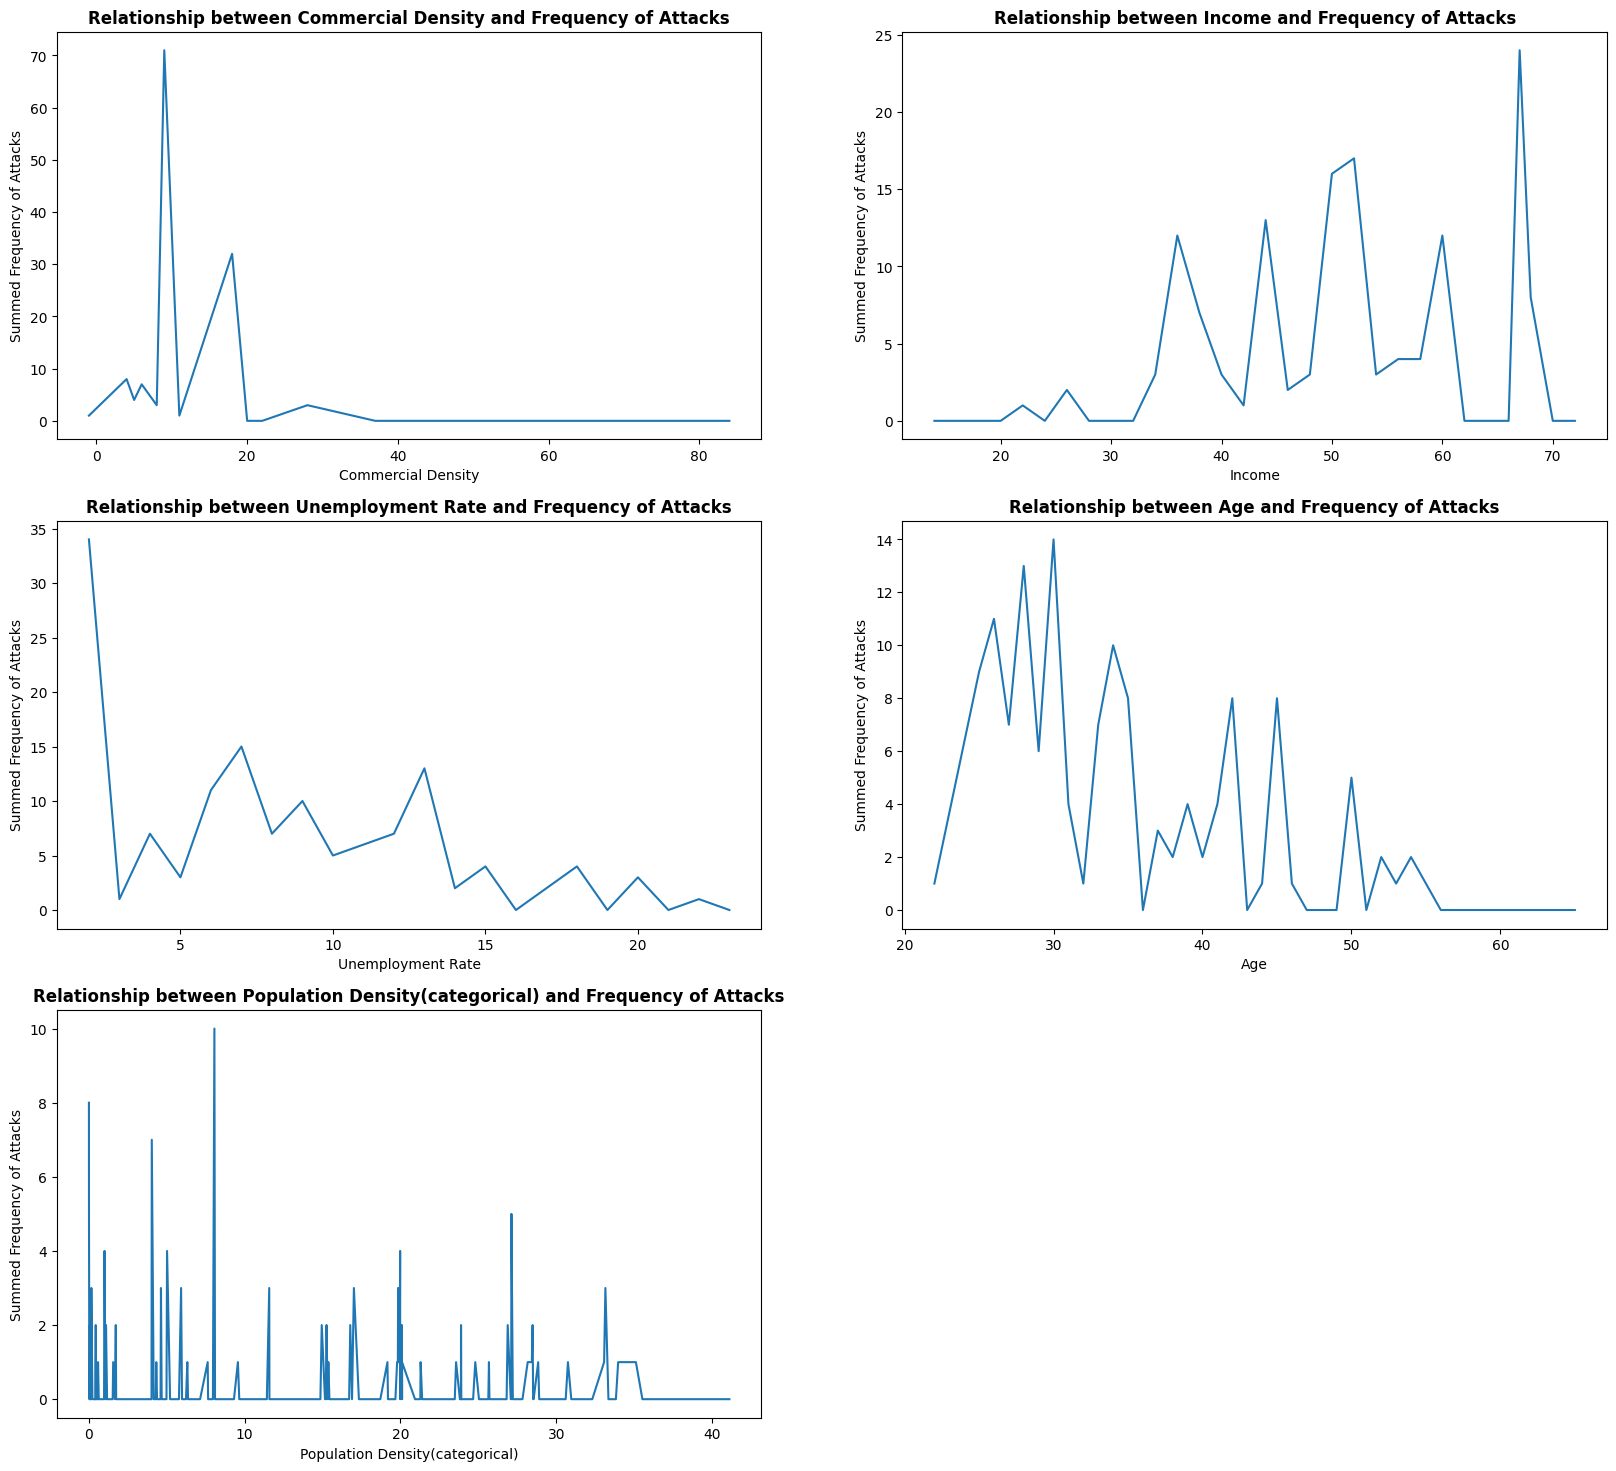

In [10]:


# Assuming df is your DataFrame with the specified columns
# df = df[['com_dens', 'income', 'unp_rate', 'age', 'freq_attack']]
f1=['Commercial Density','Income','Unemployment Rate','Age','Population Density(categorical)']

# Summing up the frequency of attacks
sum_freq_attack = df['freq_attack'].sum()

# Create an array with random noise for the x-values
x_values = np.random.normal(sum_freq_attack, 0.1, size=len(df))

# Plotting
fig=plt.figure(figsize=(20,18))
i=0
j=1
for col in ['com_dens', 'income', 'unp_rate', 'age','density']:
    axi=fig.add_subplot(3,2,j)
    df0=df[[col,'freq_attack']].groupby(col).sum().reset_index()
    df0.plot(kind='line',y='freq_attack', x=col,ax=axi)
    # Customize the plot
    plt.ylabel('Summed Frequency of Attacks')
    plt.xlabel(f1[i])
    plt.legend([],frameon=False)
    #axi.set_xticks(np.arange(0,max[df[col],10]))
    plt.title('Relationship between '+f1[i]+' and Frequency of Attacks',fontweight='bold')
    #ax.legend()
    #plt.grid(True)
    i=i+1
    j=j+1

array([[<Axes: title={'center': 'com_dens'}>,
        <Axes: title={'center': 'income'}>],
       [<Axes: title={'center': 'unp_rate'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'freq_attack'}>, <Axes: >]], dtype=object)

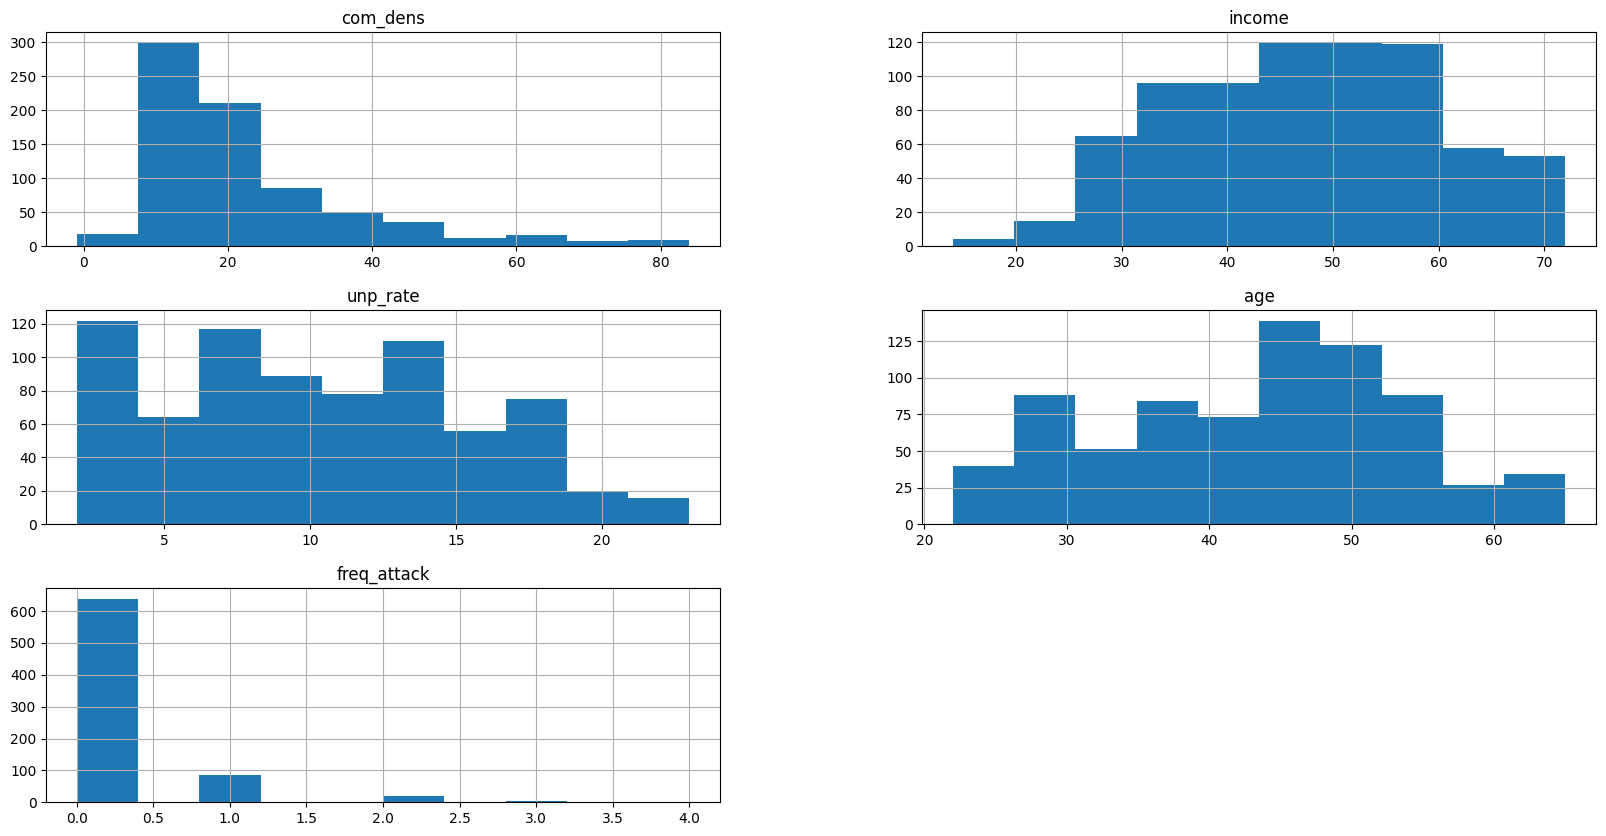

In [11]:
dfx=df[['com_dens', 'income', 'unp_rate', 'age', 'freq_attack']]
dfx.hist(figsize=(20,10))

In [12]:


# Create a scatter plot
plt.figure(figsize=(8, 6))

# Plot data points where n_freq_attack is 1 (triangle)
plt.scatter(df.loc[df['n_freq_attack'] == 1, 'mway_dist'], 
            df.loc[df['n_freq_attack'] == 1, 'police_dis'], 
            color='blue', marker='^', label='Attacked')

# Plot data points where n_freq_attack is 0 (circle)
plt.scatter(df.loc[df['n_freq_attack'] == 0, 'mway_dist'], 
            df.loc[df['n_freq_attack'] == 0, 'police_dis'], 
            color='red', marker='*', label='Not attacked')

# Add labels and title
plt.xlabel('M-way Distance')
plt.ylabel('Police Distance')
plt.title('Relation of M-way Distance & Police Distance with Attacked ATMs')
plt.legend()

# Show plot

plt.show()


KeyError: 'n_freq_attack'

<Figure size 800x600 with 0 Axes>

            freguesia  atm_id  freq_attack
0           Alcântara      22            0
1            Alvalade      41            1
2             Areeiro       8            0
3             Arroios      66            0
4      Avenidas Novas     124           19
5               Belém      23            6
6             Benfica      21            6
7    Campo de Ourique      32            0
8           Campolide      30            7
9             Carnide      53           32
10            Estrela      11            0
11             Lumiar      58           29
12            Marvila      27            0
13       MisericOrdia      15            0
14            Olivais      29            5
15      Parque das Na      46            0
16    Penha de Franea       7            0
17  Santa Maria Maior      59            0
18      Santo Antonio      45            0
19        Suo Vicente       6            0


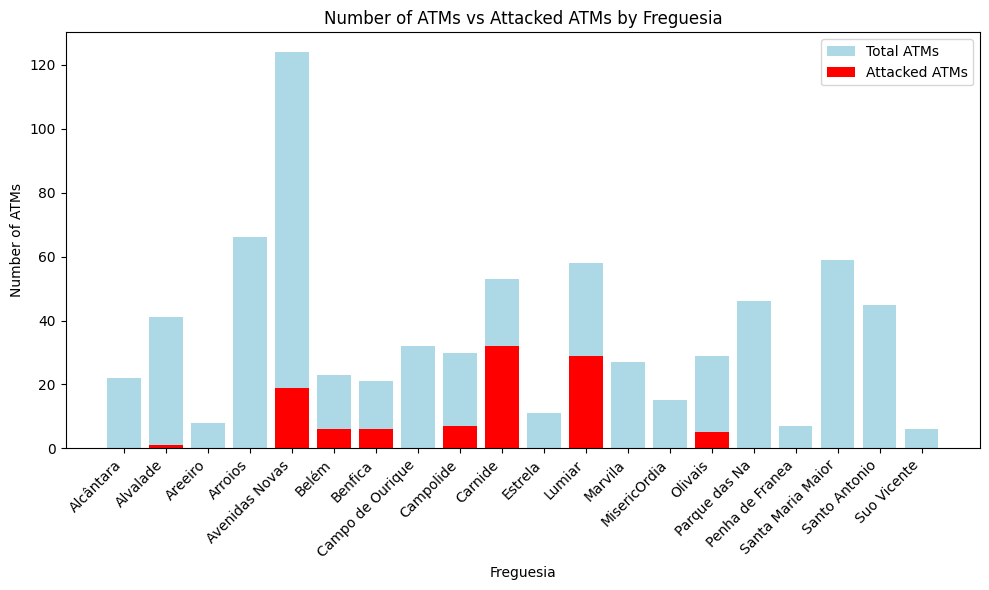

In [13]:
# Grouping by 'freguesia' and aggregating to get the total number of ATMs and the number of attacked ATMs
grouped_df = df.groupby('freguesia').agg({'atm_id': 'count', 'freq_attack': 'sum'}).reset_index()
print(grouped_df)
# Sort the DataFrame by 'freguesia'
grouped_df = grouped_df.sort_values(by='freguesia')

# Creating the bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(grouped_df['freguesia'], grouped_df['atm_id'], color='lightblue', label='Total ATMs')
bars2 = plt.bar(grouped_df['freguesia'], grouped_df['freq_attack'], color='red', label='Attacked ATMs')
plt.xlabel('Freguesia')
plt.ylabel('Number of ATMs')
plt.title('Number of ATMs vs Attacked ATMs by Freguesia')
plt.legend()
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels
plt.tight_layout()
plt.show()

In [14]:

# Define grid resolution (in degrees)
resolution = 0.01

# Define latitude and longitude boundaries for your area of interest
min_lat, max_lat = min(df['coord_y']), max(df['coord_y'])
min_lon, max_lon = min(df['coord_x']), max(df['coord_x'])

print("Minimum Latitude:", min_lat)
print("Maximum Latitude:", max_lat)
print("Minimum Longitude:", min_lon)
print("Maximum Longitude:", max_lon)

# Generate grid cells
latitudes = np.arange(min_lat, max_lat, resolution)
longitudes = np.arange(min_lon, max_lon, resolution)

# Create a dictionary to store grid cell boundaries and IDs
grid = {}
grid_id = 0

# Assign IDs to grid cells and store their boundaries
for lat_start, lat_end in zip(latitudes[:-1], latitudes[1:]):
    for lon_start, lon_end in zip(longitudes[:-1], longitudes[1:]):
        grid[(lat_start, lon_start)] = {
            'id': grid_id,
            'lat_start': lat_start,
            'lat_end': lat_end,
            'lon_start': lon_start,
            'lon_end': lon_end
        }
        grid_id += 1

# Print the number of grid cells created
print("Number of grid cells:", len(grid))
# Calculate the size of each grid cell




Minimum Latitude: 38.69599
Maximum Latitude: 38.79159
Minimum Longitude: -9.22544
Maximum Longitude: -9.09196
Number of grid cells: 117


In [15]:


# Load the GeoJSON file containing the outline of Lisbon
with open('lisbon.geojson') as f:
    lisbon_geojson = json.load(f)

# Define the minimum and maximum latitude and longitude
min_lat = 38.69599
max_lat = 38.79159
min_lon = -9.22544
max_lon = -9.09196

# Create a folium map centered around the average coordinates of your data
map_center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
m = folium.Map(location=map_center, zoom_start=10, tiles='cartodbpositron')

# Add the GeoJSON overlay for the outline of Lisbon
folium.GeoJson(
    lisbon_geojson,
    style_function=lambda feature: {
        'color': 'black',  # Outline color
        'weight': 2  # Outline weight
    }
).add_to(m)

# Define the number of grid cells
num_lat_cells = 10
num_lon_cells = 10

# Calculate the size of each grid cell
lat_step = (max_lat - min_lat) / num_lat_cells
lon_step = (max_lon - min_lon) / num_lon_cells

# Generate latitude and longitude values for the grid cells
latitudes = [min_lat + i * lat_step for i in range(num_lat_cells)]
longitudes = [min_lon + i * lon_step for i in range(num_lon_cells)]

# Create legend
legend_html = '''
 <div style="position: fixed; 
            bottom: 50px; left: 50px; width: 150px; height: 160px; 
            border: 2px solid grey; border-radius: 10px; background-color: rgba(255, 255, 255, 0.9);
            z-index: 9999; font-size: 14px; padding: 10px; text-align: center;">
    <div style="font-weight: bold;">Frequency of Attacks</div>
    <div style="margin-top: 10px;">
        <div style="display: inline-block; width: 20px; height: 20px; background-color: rgba(0, 0, 0, 0.5); border-radius: 50%;"></div>
        <span style="margin-left: 5px;">1-2</span>
    </div>
    <div style="margin-top: 5px;">
        <div style="display: inline-block; width: 20px; height: 20px; background-color: rgba(0, 0, 0, 0.7); border-radius: 50%;"></div>
        <span style="margin-left: 5px;">3-4</span>
    </div>
    <div style="margin-top: 5px;">
        <div style="display: inline-block; width: 20px; height: 20px; background-color: rgba(0, 0, 0, 1.0); border-radius: 50%;"></div>
        <span style="margin-left: 5px;">>4</span>
    </div>
</div>

     '''
m.get_root().html.add_child(folium.Element(legend_html))

# Add grid cells as polygons to the map for cells with non-zero frequency of attacks
for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        # Define the coordinates of the four corners of the grid cell
        coordinates = [
            [lat, lon],
            [lat + lat_step, lon],
            [lat + lat_step, lon + lon_step],
            [lat, lon + lon_step],
            [lat, lon]  # To close the polygon
        ]
        # Calculate the frequency of attacks for this grid cell
        freq_attacks = df[
            (df['coord_y'] >= lat) & (df['coord_y'] < lat + lat_step) &
            (df['coord_x'] >= lon) & (df['coord_x'] < lon + lon_step)
        ]['freq_attack'].sum()

        # If the frequency of attacks is non-zero, add the polygon to the map
        if freq_attacks > 0:
            # Calculate opacity based on frequency of attacks
            opacity = min(0.5 + 0.1 * freq_attacks, 1.0)  # Adjust as needed
            # Create a color gradient from light to dark
            color = f'rgba(0, 0, 0, {opacity})'
            # Add the polygon with the gradient fill
            folium.Polygon(
                locations=coordinates,
                color=color,
                fill_color=color,
                fill_opacity=1.0
            ).add_to(m)



# Display the map
m



In [16]:
import folium
from folium.plugins import HeatMap

# Extracting coordinates and frequency of attacks from the DataFrame
coordinates = df[['coord_y', 'coord_x']].values
freq_attack = df['freq_attack'].values

# Convert frequency values to regular Python integers
freq_attack = freq_attack.astype(int)

# Create a folium map centered around the average coordinates of your data
avg_lat = coordinates[:, 0].mean()
avg_lon = coordinates[:, 1].mean()
map_center = [avg_lat, avg_lon]
m = folium.Map(location=map_center, zoom_start=10)

# Combine the coordinates and frequency of attacks into a list of lists
data = [[coord[0], coord[1], int(freq)] for coord, freq in zip(coordinates, freq_attack)]

# Create a HeatMap layer using the combined data
heatmap_layer = HeatMap(data=data,
                        min_opacity=0.2,
                        radius=25, blur=15)

# Add the HeatMap layer to the map
m.add_child(heatmap_layer)

# Display the map
m
